In [1]:
from meta import *
import pandas as pd
import numpy as np

df = pd.read_csv(datapath+r"\climate_prep.csv", encoding="utf-8")

In [2]:
from sklearn.model_selection import train_test_split

train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(len(train_df), len(val_df), len(test_df))

294156 63033 63035


In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

In [4]:
temp_idx = train_df.columns.get_loc("T (degC)")
hum_idx = train_df.columns.get_loc("rh (%)")

target_cols = [temp_idx, hum_idx]

In [5]:
import numpy as np

def create_sequences(data, window_size, target_cols):

    X = []
    y = []

    for i in range(len(data) - window_size):

        X.append(data[i:i + window_size])

        y.append(data[i + window_size, target_cols])

    return np.array(X), np.array(y)

In [6]:
WINDOW = 24

In [7]:
X_train, y_train = create_sequences(
    train_scaled,
    WINDOW,
    target_cols
)

X_val, y_val = create_sequences(
    val_scaled,
    WINDOW,
    target_cols
)

X_test, y_test = create_sequences(
    test_scaled,
    WINDOW,
    target_cols
)

In [8]:
print(X_train.shape)
print(y_train.shape)

(294132, 24, 24)
(294132, 2)


In [9]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Input
)
from tensorflow.keras.models import Model

In [10]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):

    x = LayerNormalization(epsilon=1e-6)(inputs)

    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(x, x)

    x = Dropout(dropout)(x)

    res = x + inputs

    x = LayerNormalization(epsilon=1e-6)(res)

    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)

    return x + res

In [11]:
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

x = transformer_encoder(
    inputs,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
)

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation="leaky_relu")(x)
x = Dropout(0.3)(x)

x = Dense(32, activation="leaky_relu")(x)

outputs = Dense(2)(x)

model = Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 24)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 24)    │         48 │ input_layer[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 24)    │     25,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 24)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 24)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 24)    │         48 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 128)   │      3,200 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24, 24)    │      3,096 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 24)    │          0 │ dense_1[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 24)        │          0 │ add_1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      1,600 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2)         │         66 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,506 (138.70 KB)

 Trainable params: 35,506 (138.70 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [13]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=15,

    batch_size=64,

    callbacks=[early_stop]
)

Epoch 1/15
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 130s 27ms/step - loss: 0.0025 - mae: 0.0312 - val_loss: 0.5710 - val_mae: 0.0502
Epoch 2/15
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 123s 27ms/step - loss: 5.3352e-04 - mae: 0.0166 - val_loss: 0.0492 - val_mae: 0.0495
Epoch 3/15
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 125s 27ms/step - loss: 4.2983e-04 - mae: 0.0147 - val_loss: 0.0113 - val_mae: 0.0516
Epoch 4/15
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 122s 27ms/step - loss: 3.8144e-04 - mae: 0.0138 - val_loss: 0.0184 - val_mae: 0.0514
Epoch 5/15
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 124s 27ms/step - loss: 3.4490e-04 - mae: 0.0130 - val_loss: 0.0085 - val_mae: 0.0521
Epoch 6/15
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 123s 27ms/step - loss: 3.2093e-04 - mae: 0.0125 - val_loss: 0.0108 - val_mae: 0.0494
Epoch 7/15
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 129s 28ms/step - loss: 3.0360e-04 - mae: 0.0120 - val_loss: 0.0064 - val_mae: 0.0486
Epoch 8/15
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 133s 29ms/step - loss: 2.9181e-04 - mae: 0.0118 - val_loss: 0.0101 - val_

In [14]:
y_pred = model.predict(X_test)

1970/1970 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step


MODEL PERFORMANCE

Temperature
MAE  : 1.763 °C
RMSE : 2.154 °C
R²   : 0.9234

Humidity
MAE  : 5.347 %
RMSE : 6.088 %
R²   : 0.8469


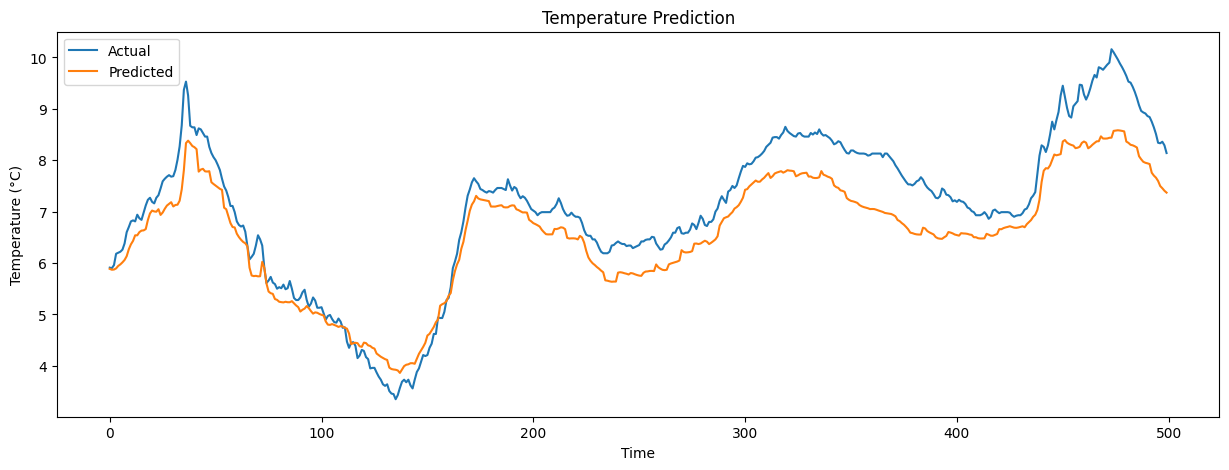

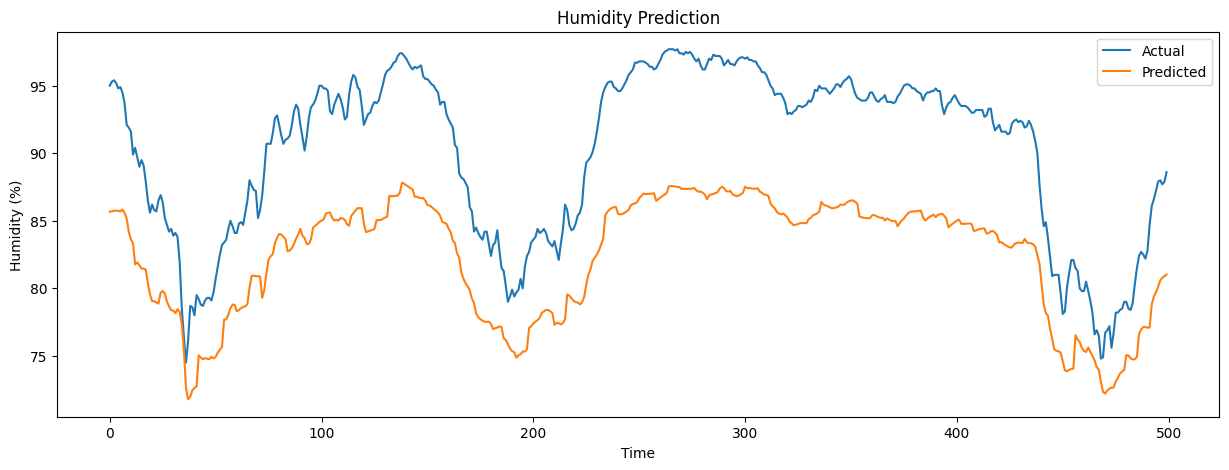

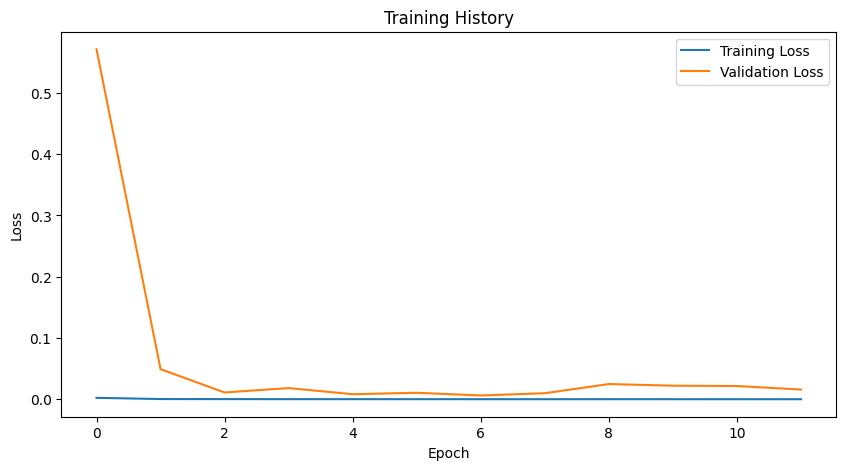

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ================================
# Inverse Transform Predictions
# ================================

temp_idx = train_df.columns.get_loc("T (degC)")
hum_idx = train_df.columns.get_loc("rh (%)")

n_features = train_df.shape[1]

dummy_true = np.zeros((len(y_test), n_features))
dummy_pred = np.zeros((len(y_pred), n_features))

dummy_true[:, temp_idx] = y_test[:, 0]
dummy_true[:, hum_idx] = y_test[:, 1]

dummy_pred[:, temp_idx] = y_pred[:, 0]
dummy_pred[:, hum_idx] = y_pred[:, 1]

true_inverse = scaler.inverse_transform(dummy_true)
pred_inverse = scaler.inverse_transform(dummy_pred)

true_temp = true_inverse[:, temp_idx]
true_hum = true_inverse[:, hum_idx]

pred_temp = pred_inverse[:, temp_idx]
pred_hum = pred_inverse[:, hum_idx]

# ================================
# Metrics
# ================================

temp_mae = mean_absolute_error(true_temp, pred_temp)
temp_rmse = np.sqrt(mean_squared_error(true_temp, pred_temp))
temp_r2 = r2_score(true_temp, pred_temp)

hum_mae = mean_absolute_error(true_hum, pred_hum)
hum_rmse = np.sqrt(mean_squared_error(true_hum, pred_hum))
hum_r2 = r2_score(true_hum, pred_hum)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print("\nTemperature")
print(f"MAE  : {temp_mae:.3f} °C")
print(f"RMSE : {temp_rmse:.3f} °C")
print(f"R²   : {temp_r2:.4f}")

print("\nHumidity")
print(f"MAE  : {hum_mae:.3f} %")
print(f"RMSE : {hum_rmse:.3f} %")
print(f"R²   : {hum_r2:.4f}")

# ================================
# Temperature Plot
# ================================

plt.figure(figsize=(15,5))

plt.plot(true_temp[:500], label="Actual")
plt.plot(pred_temp[:500], label="Predicted")

plt.title("Temperature Prediction")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

# ================================
# Humidity Plot
# ================================

plt.figure(figsize=(15,5))

plt.plot(true_hum[:500], label="Actual")
plt.plot(pred_hum[:500], label="Predicted")

plt.title("Humidity Prediction")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()

plt.show()

# ================================
# Training Curve
# ================================

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()